# Data Composition

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [7]:
df.isnull().sum() # Count mising values

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df.isnull().sum() / len(df) * 100 # Percentage of missing valuesin each column

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

<Axes: >

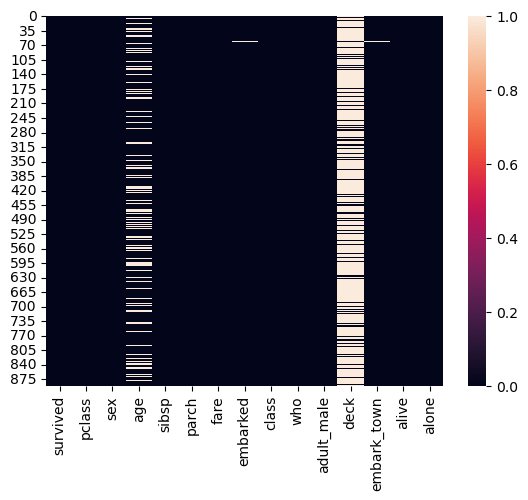

In [9]:
sns.heatmap(df.isnull()) # Missing values using graphs

In [11]:
df.shape

(891, 15)

In [12]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Pandas ki mazeed Tips

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Imputing Missing Values

# Missing Value Imputation: Complete Guide

---

## 1. What Are Missing Values?

Missing values are data points that are not recorded.

**Example:**

| Name | Age | Salary |
|------|-----|--------|
| Ali  | 25  | 50k    |
| Sara | NaN | 60k    |
| John | 30  | NaN    |

- `NaN` = Not a Number (missing value)
- Models **cannot handle missing values directly**, so we must fix them

---

## 2. Why Values Are Missing (Critical)

Before filling missing values, understand the reason:

---

### 2.1 MCAR (Missing Completely At Random)
- Missing randomly, no pattern
- Example: Someone forgot to fill a form
- Safe to use simple methods

---

### 2.2 MAR (Missing At Random)
- Missing depends on other columns
- Example: Salary missing mostly for young people
- Use smarter methods (KNN, regression)

---

### 2.3 MNAR (Missing Not At Random)
- Missing depends on itself
- Example: Low-income people hide salary
- Hard case — must be handled carefully

---

## 3. Basic Imputation Methods

---

### 3.1 Mean Imputation

Replace missing values with average.

```python
df['Age'].fillna(df['Age'].mean(), inplace=True)
```

**Use when:**
- Data is normally distributed
- Missing percentage is small

**Problems:**
- Reduces variance
- Affected by outliers

---

### 3.2 Median Imputation (Best Default)

Replace with middle value.

```python
df['Age'].fillna(df['Age'].median(), inplace=True)
```

**Use when:**
- Data is skewed (very common)
- Safer than mean

---

### 3.3 Mode Imputation

For categorical data.

```python
df['City'].fillna(df['City'].mode()[0], inplace=True)
```

**Use when:**
- Data is text or categorical

---

### 3.4 Constant Value Imputation

```python
df['City'].fillna("Unknown", inplace=True)
df['Age'].fillna(0, inplace=True)
```

**Use when:**
- Missing itself has meaning

---

### 3.5 Forward Fill / Backward Fill (Time Series)

```python
df.fillna(method='ffill')
df.fillna(method='bfill')
```

**Use when:**
- Time-based or sequential data

---

## 4. Advanced Imputation Methods

---

### 4.1 KNN Imputation

Uses nearest neighbors to estimate values.

```python
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
df_imputed = imputer.fit_transform(df)
```

**Idea:**
- Find similar rows
- Use their values to fill missing data

**Use when:**
- Features are correlated

**Problems:**
- Slow for large datasets
- Needs scaling

---

### 4.2 Regression Imputation

Predict missing values using other features.

**Steps:**
1. Select rows without missing values
2. Train a model
3. Predict missing values

**Use when:**
- Strong relationships between variables

**Problems:**
- Can overfit
- Underestimates variability

---

### 4.3 Iterative Imputer (MICE)

```python
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
df_imputed = imputer.fit_transform(df)
```

**Idea:**
- Predict missing values multiple times
- Improves accuracy each iteration

**Use when:**
- Complex datasets
- High accuracy needed

**Problems:**
- Computationally expensive

---

## 5. Dropping Data

```python
df.dropna()
```

**Use when:**
- Very few missing values

```python
df.drop(columns=['column_name'])
```

**Use when:**
- Column has more than 50% missing values

---

## 6. Missing Indicator (Pro Trick)

```python
df['Age_missing'] = df['Age'].isnull().astype(int)
```

**Why use it?**
- Model learns that "missing" itself is important information

---

## 7. When To Use What — Decision Guide

| Situation | Method |
|---|---|
| Less than 5% missing | Median |
| Skewed data | Median |
| Normal data | Mean |
| Categorical | Mode / "Unknown" |
| Time series | Forward Fill |
| Correlated features | KNN / Regression |
| Complex dataset | Iterative Imputer |
| More than 50% missing | Drop column |
| Missing has meaning | Add indicator |

---

## 8. Common Mistakes

**Wrong Way (Data Leakage):**

```python
df.fillna(df.mean())
train_test_split(df)
```

**Correct Way:**

```python
train, test = train_test_split(df)
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(train['Age'].median(), inplace=True)
```

> Always fit on train, apply on test.

---

## 9. Real-World Strategy

1. Start simple: Median / Mode
2. Add: Missing indicator
3. Try advanced: KNN / Iterative
4. Compare model performance

---

## 10. Pro Tips

- Median outperforms mean in most real datasets
- Tree-based models (XGBoost, LightGBM) handle missing values natively
- Always check missing patterns before imputing
- Never blindly apply complex methods

---

## Final Insight

Handling missing values is not just filling numbers. It is about preserving the true pattern of data.

- Bad imputation = bad model
- Good imputation = strong model

In [14]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:
df.isnull().sum() / len(df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

##### Drop the column having more than 70% values from dataset

In [16]:
df.drop("deck", axis=1, inplace=True) # You can use inplace = True as well 

#### Filling missing values of the column by mean (for normal data)

In [17]:
df["age"] = df["age"].fillna(df["age"].mean(), inplace=True)

/tmp/ipykernel_90486/2553199102.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["age"] = df["age"].fillna(df["age"].mean(), inplace=True)


#### Filling missing values of the column by median (for skewed data)

In [18]:
df["age"] = df["age"].fillna(df["age"].median()) # You can use inplace=True

In [19]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

#### Filling missing values of the column by mode (for categorical data)

In [20]:
df["embark_town"].mode()

0    Southampton
Name: embark_town, dtype: str

In [21]:
df["embark_town"].mode()[0]

'Southampton'

In [22]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0]) # You can use inplace=True

In [23]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0]) # You can use inplace=True

In [24]:
df["embarked"].dtype

<StringDtype(storage='python', na_value=nan)>

In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [26]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

<Axes: >

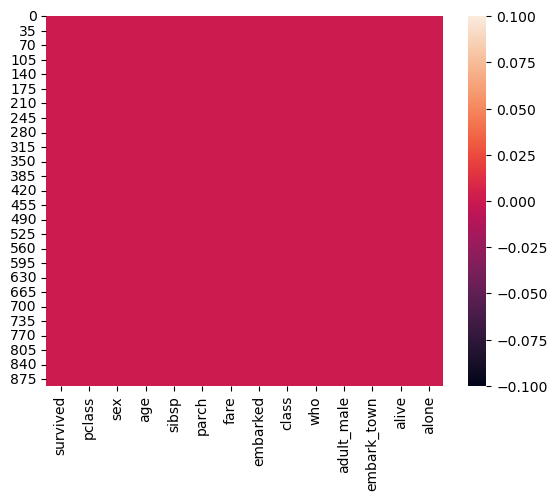

In [28]:
sns.heatmap(df.isnull())

# What Happens If You Do Not Impute or Handle Missing Values?

---

## 1. Errors in ML Models

Most machine learning algorithms cannot process `NaN` values directly. If you feed a dataset with missing values into a model, it will throw an error and refuse to train.

```python
from sklearn.linear_model import LinearRegression
import seaborn as sns

df = sns.load_dataset("titanic")

X = df[["age", "fare"]]
y = df["survived"]

model = LinearRegression()
model.fit(X, y)
```

**Output:**
```
ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively.
```

---

## 2. Incorrect Statistical Results

Missing values silently corrupt your descriptive statistics. The mean, median, and standard deviation will be calculated only over non-null rows, which may not represent the true distribution of your data.

```python
import seaborn as sns

df = sns.load_dataset("titanic")

print("Mean age (with nulls):", df["age"].mean())
print("Count used:", df["age"].count(), "out of", len(df))
```

**Output:**
```
Mean age (with nulls): 29.69911764705882
Count used: 714 out of 891
```

The mean is computed over only 714 passengers. The 177 missing ages are completely ignored, which may skew the result if the missing ages follow a pattern (e.g., children or elderly passengers were more likely to have missing records).

---

## 3. Loss of Rows During Preprocessing

When you apply `dropna()` to remove rows with missing values, you silently lose a significant portion of your data.

```python
import seaborn as sns

df = sns.load_dataset("titanic")

print("Before dropna:", df.shape)
df_cleaned = df.dropna()
print("After dropna:", df_cleaned.shape)
```

**Output:**
```
Before dropna: (891, 15)
After dropna: (182, 15)
```

Dropping all rows with any null value reduces the dataset from 891 rows to only 182 rows. That is an 80% loss of data just because the `deck` column alone has 688 missing values.

---

## 4. Biased or Misleading Analysis

If the missing values are not random (called Missing Not At Random, or MNAR), ignoring them introduces bias into your analysis. For example, if wealthier passengers are more likely to have their age recorded, then dropping missing age values will cause your model to over-represent wealthy passengers.

```python
import seaborn as sns

df = sns.load_dataset("titanic")

missing_age = df[df["age"].isnull()]
present_age = df[df["age"].notnull()]

print("Average fare (missing age):", missing_age["fare"].mean())
print("Average fare (present age):", present_age["fare"].mean())
```

**Output:**
```
Average fare (missing age): 22.16
Average fare (present age): 32.98
```

Passengers with missing ages paid lower fares on average, which suggests the missing data is not random. Ignoring this introduces bias.

---

## 5. Poor Model Performance

Even if a model somehow handles nulls internally (such as some tree-based models), the missing values carry no useful signal. Imputed values, even simple ones like the mean or mode, give the model more information to learn from compared to nothing at all.

---

## Summary Table

| Consequence | Description |
|---|---|
| Model errors | Most sklearn models crash on NaN input |
| Skewed statistics | Mean/std are computed on incomplete data |
| Data loss | dropna() can remove up to 80% of rows |
| Biased analysis | Non-random missing data introduces systematic bias |
| Poor performance | Models trained on incomplete data generalize worse |

---

## Correct Approach

```python
import seaborn as sns

df = sns.load_dataset("titanic")

# Numeric column: fill with median
df["age"] = df["age"].fillna(df["age"].median())

# Categorical columns: fill with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

print(df[["age", "embarked", "embark_town"]].isnull().sum())
```

**Output:**
```
age            0
embarked       0
embark_town    0
dtype: int64
```

Always handle missing values before proceeding to any analysis or model training.